# Thermal Video Degradation Simulator Demo (Proposal 3.3)

**Objective:** Demonstrate and visualize the on-the-fly degradation pipeline specified in Proposal Section 3.3.

The pipeline simulates realistic uncooled thermal camera degradations:
1. **Low contrast** (dynamic range compression): ratio in {60%, 40%, 25%}
2. **Optical blur** (Gaussian smoothing): sigma_b in {1.0, 2.0, 3.0} px
3. **Fixed pattern stripes** (constant column non-uniformity): sigma_s in {2.0, 4.0, 8.0}
4. **Temporal stripes** (per-frame column fluctuations): sigma_l in {1.0, 2.0, 4.0}
5. **Random noise** (independent spatial-temporal Gaussian): sigma_t in {3.0, 6.0, 12.0}

In [1]:
import sys
from pathlib import Path

# Ensure src/ is on sys.path regardless of which Jupyter kernel is selected
src_dir = str(Path("../src").resolve())
if src_dir not in sys.path:
    sys.path.insert(0, src_dir)

import matplotlib.pyplot as plt
import numpy as np

from thermal_restore.data.loader import list_sequences, load_sequence
from thermal_restore.data.visualization import stretch_contrast
from thermal_restore.degradation import (
    LEVELS,
    compress_contrast,
    degrade,
    fixed_stripes,
    gaussian_blur,
    gaussian_noise,
    temporal_stripes,
)

DATA_ROOT = Path("../data/FLIR_ADAS_v2")
SEED = 42

## 1. Load Sample Video Sequence

Load consecutive frames from a sequence in `FLIR_ADAS_v2` to evaluate spatial and temporal degradations.

Loaded sequence video-24ysbPEGoEKKDvRt6: (5, 512, 640), dtype=float32
Range: [99.4, 133.9], mean=116.7


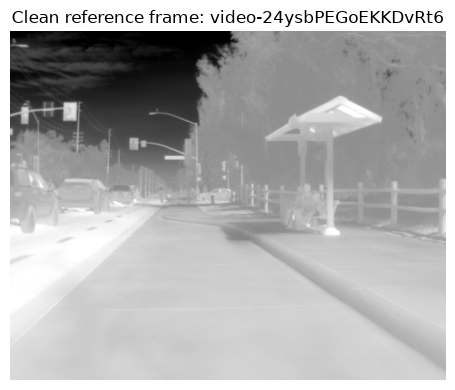

In [2]:
sequences = list_sequences(DATA_ROOT)
seq_id = min(sequences.keys())
frame_paths = sequences[seq_id][:5]
frames = load_sequence(frame_paths)

print(f"Loaded sequence {seq_id}: {frames.shape}, dtype={frames.dtype}")
print(f"Range: [{frames.min():.1f}, {frames.max():.1f}], mean={frames.mean():.1f}")

plt.figure(figsize=(6, 4))
plt.imshow(stretch_contrast(frames[0]), cmap="gray")
plt.title(f"Clean reference frame: {seq_id}")
plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Individual Degradation Types Across 3 Levels

Inspect each operator in isolation at Light, Medium, and Heavy levels.

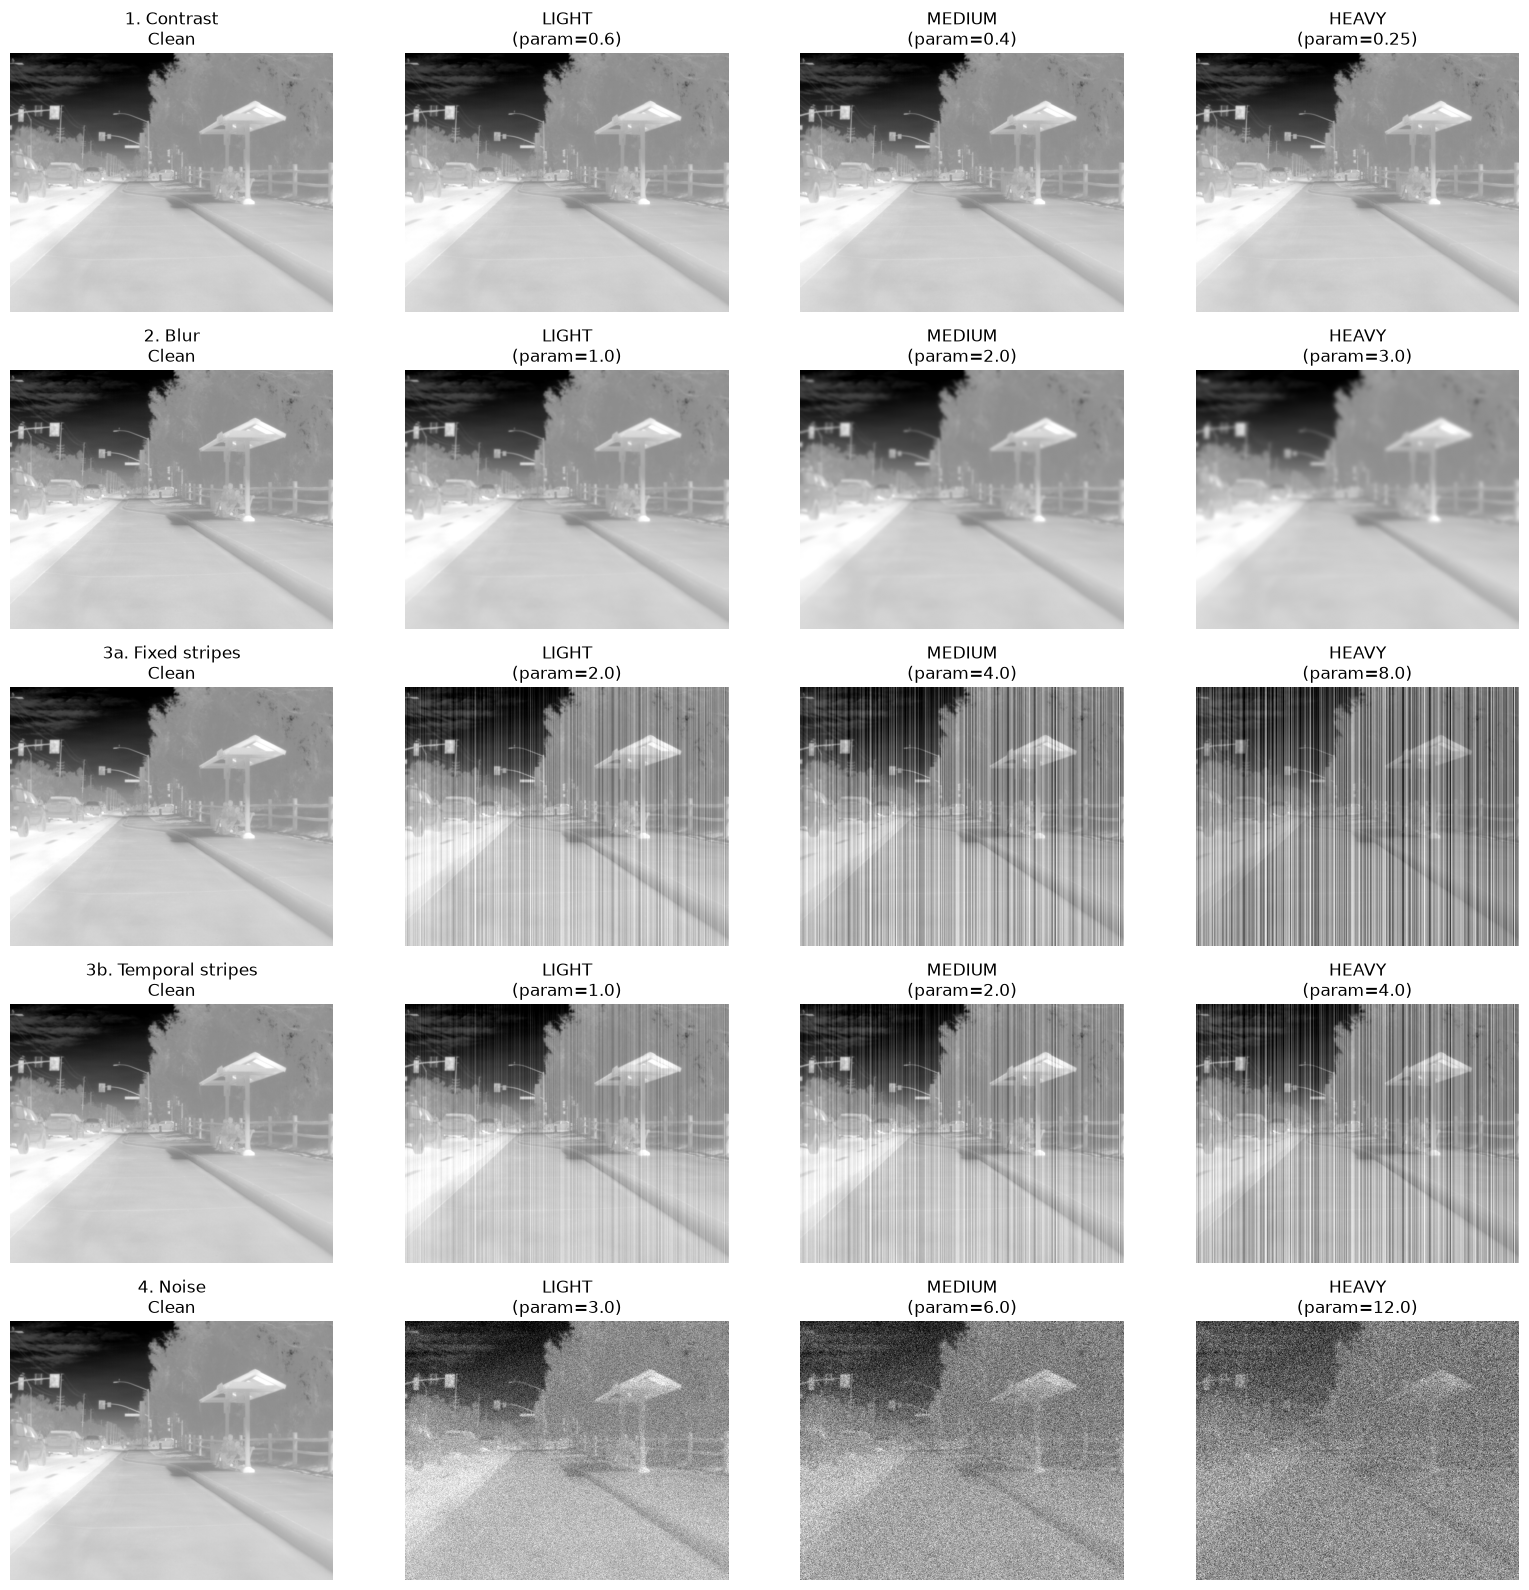

In [3]:
levels = ["light", "medium", "heavy"]
fig, axes = plt.subplots(5, 4, figsize=(16, 16))

ops = [
    (
        "1. Contrast",
        lambda f, lvl, r: compress_contrast(f, factor=LEVELS[lvl]["contrast"]),
    ),
    ("2. Blur", lambda f, lvl, r: gaussian_blur(f, sigma=LEVELS[lvl]["blur"])),
    (
        "3a. Fixed stripes",
        lambda f, lvl, r: fixed_stripes(f, sigma=LEVELS[lvl]["fixed_stripes"], rng=r),
    ),
    (
        "3b. Temporal stripes",
        lambda f, lvl, r: temporal_stripes(
            f, sigma=LEVELS[lvl]["temporal_stripes"], rng=r
        ),
    ),
    (
        "4. Noise",
        lambda f, lvl, r: gaussian_noise(f, sigma=LEVELS[lvl]["noise"], rng=r),
    ),
]

for row_idx, (name, fn) in enumerate(ops):
    axes[row_idx, 0].imshow(stretch_contrast(frames[0]), cmap="gray")
    axes[row_idx, 0].set_title(f"{name}\nClean")
    axes[row_idx, 0].axis("off")
    for col_idx, lvl in enumerate(levels):
        rng = np.random.default_rng(SEED)
        deg = fn(frames, lvl, rng)
        axes[row_idx, col_idx + 1].imshow(stretch_contrast(deg[0]), cmap="gray")
        param_val = list(LEVELS[lvl].values())[row_idx]
        axes[row_idx, col_idx + 1].set_title(f"{lvl.upper()}\n(param={param_val})")
        axes[row_idx, col_idx + 1].axis("off")

plt.tight_layout()
plt.show()

## 3. Full End-to-End Degradation Pipeline

Combine all operations in order: contrast compression -> blur -> fixed stripes -> temporal stripes -> noise.

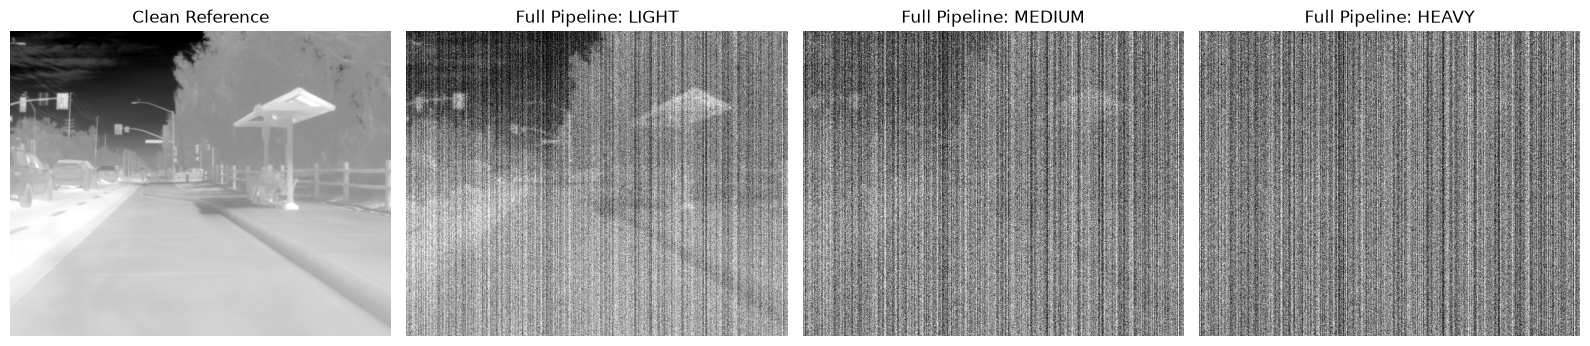

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(stretch_contrast(frames[0]), cmap="gray")
axes[0].set_title("Clean Reference")
axes[0].axis("off")

for idx, lvl in enumerate(levels):
    out = degrade(frames, level=lvl, rng=SEED)
    axes[idx + 1].imshow(stretch_contrast(out[0]), cmap="gray")
    axes[idx + 1].set_title(f"Full Pipeline: {lvl.upper()}")
    axes[idx + 1].axis("off")

plt.tight_layout()
plt.show()

## 4. Temporal Consistency Analysis

Compare absolute difference between consecutive frames $|I_{t+1} - I_t|$:
- **Fixed pattern stripes:** The offsets are identical for all frames, so they cancel out completely.
- **Temporal stripes:** Varying column offsets produce vertical stripe artifacts across time.
- **Noise:** Uncorrelated across space and time.

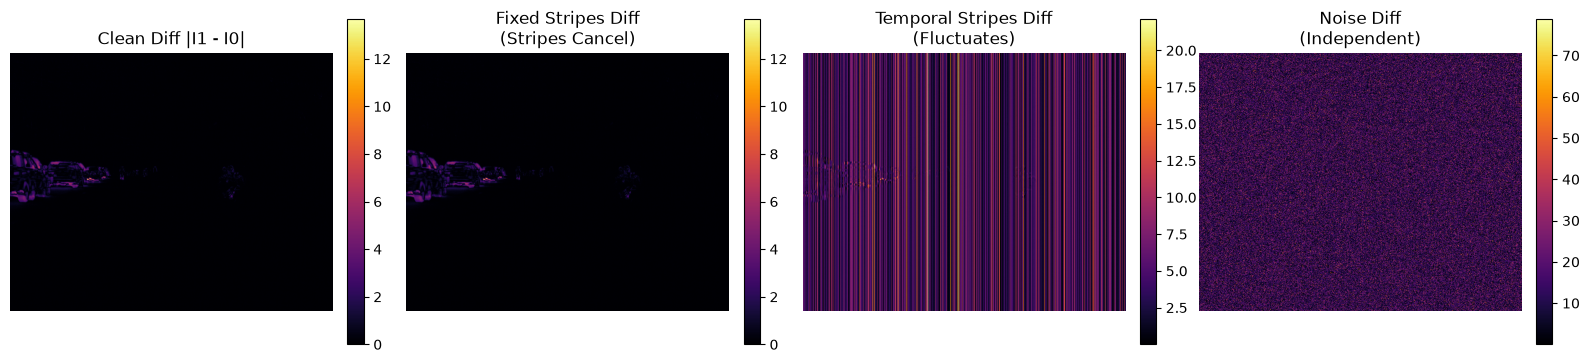

In [5]:
rng_fixed = np.random.default_rng(SEED)
fixed_seq = fixed_stripes(frames, sigma=LEVELS["heavy"]["fixed_stripes"], rng=rng_fixed)

rng_temp = np.random.default_rng(SEED)
temp_seq = temporal_stripes(
    frames, sigma=LEVELS["heavy"]["temporal_stripes"], rng=rng_temp
)

rng_noise = np.random.default_rng(SEED)
noise_seq = gaussian_noise(frames, sigma=LEVELS["heavy"]["noise"], rng=rng_noise)

diff_clean = np.abs(frames[1] - frames[0])
diff_fixed = np.abs(fixed_seq[1] - fixed_seq[0])
diff_temp = np.abs(temp_seq[1] - temp_seq[0])
diff_noise = np.abs(noise_seq[1] - noise_seq[0])

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
diffs = [
    ("Clean Diff |I1 - I0|", diff_clean),
    ("Fixed Stripes Diff\n(Stripes Cancel)", diff_fixed),
    ("Temporal Stripes Diff\n(Fluctuates)", diff_temp),
    ("Noise Diff\n(Independent)", diff_noise),
]

for ax, (title, img) in zip(axes, diffs):
    im = ax.imshow(img, cmap="inferno")
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()